<a href="https://colab.research.google.com/github/armandoordonez/AI-Engineering/blob/main/llm_desde_cero.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Entrenar un LLM desde cero, paso a paso

Este notebook construye y entrena un **modelo de lenguaje tipo GPT completo desde cero**,
sin usar `transformers` ni tokenizadores pre-entrenados. Todo el código es ejecutable y ha
sido probado de principio a fin en CPU.

**Lo que vas a construir:**

| Paso | Contenido |
|---|---|
| 1 | Corpus de entrenamiento |
| 2 | Tokenizador **BPE** implementado desde cero |
| 3 | Dataset, ventanas de contexto y batching |
| 4 | Arquitectura GPT (atención causal multi-cabeza, MLP, bloques residuales) |
| 5 | Bucle de entrenamiento (AdamW, warmup + cosine, clipping) |
| 6 | Generación de texto (temperatura, top-k, top-p) |
| 7 | Guardar y cargar checkpoints |
| 8 | Fine-tuning por instrucciones (SFT) con enmascarado de pérdida |
| 9 | Cómo escalar: configuraciones y estimador de parámetros |

> **Nota sobre expectativas.** Con un modelo de ~1–2 M de parámetros entrenado unos minutos
> en CPU, el texto generado será gramaticalmente plausible pero sin sentido profundo. Eso es
> lo esperado: el objetivo es que **cada pieza del pipeline funcione y sea comprensible**.
> En la última sección tienes las configuraciones para escalar en GPU.

## Paso 0 · Instalación y verificación del entorno

Única dependencia obligatoria: **PyTorch**. `matplotlib` se usa solo para graficar la pérdida.
Descomenta la línea siguiente si te falta alguna.

In [ ]:
# %pip install torch matplotlib

In [ ]:
import math
import os
import json
import time
import random
import re
from collections import Counter, defaultdict
from dataclasses import dataclass, asdict

import torch
import torch.nn as nn
from torch.nn import functional as F

print("PyTorch:", torch.__version__)

# Selección de dispositivo
if torch.cuda.is_available():
    device = "cuda"
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print("Dispositivo:", device)

# Reproducibilidad
SEED = 1337
random.seed(SEED)
torch.manual_seed(SEED)
if device == "cuda":
    torch.cuda.manual_seed_all(SEED)

PyTorch: 2.13.0+cu130
Dispositivo: cpu


## Paso 1 · Los datos

Un LLM aprende a **predecir el siguiente token**. Solo necesita texto plano: sin etiquetas,
sin anotaciones. Esa es la razón por la que estos modelos pueden entrenarse con datos masivos.

Por defecto descargamos *TinyShakespeare* (~1.1 MB, dominio público), el corpus clásico para
estos experimentos. **Para usar tu propio texto**, pon la ruta de tu `.txt` en `CORPUS_PATH`
(por ejemplo, un volcado de tu documentación, libros en español, transcripciones, etc.).
Si no hay internet, se genera un corpus sintético en español para que el notebook siga siendo
ejecutable.

In [ ]:
CORPUS_PATH = None  # p. ej. "mis_datos.txt"; si es None se usa el corpus por defecto
CORPUS_URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"


def corpus_sintetico(n=6000):
    """Corpus de respaldo (sin internet). Gramática por plantillas: pequeño pero aprendible."""
    sujetos = ["el ingeniero", "la profesora", "mi vecino", "aquel estudiante", "la doctora",
               "el arquitecto", "una investigadora", "el panadero", "la abogada", "tu hermano"]
    verbos = ["revisó", "construyó", "explicó", "olvidó", "encontró", "diseñó", "compartió",
              "cuestionó", "midió", "reparó"]
    objetos = ["el informe anual", "un modelo de lenguaje", "la propuesta del cliente",
               "tres cuadernos viejos", "el plano de la casa", "la receta de su abuela",
               "un algoritmo curioso", "la lista de tareas", "el resultado del experimento"]
    lugares = ["en la biblioteca", "durante la reunión", "antes del amanecer", "en el laboratorio",
               "mientras llovía", "en la cocina", "junto a la ventana", "después del viaje"]
    rng = random.Random(0)
    lineas = []
    for _ in range(n):
        lineas.append(f"{rng.choice(sujetos).capitalize()} {rng.choice(verbos)} "
                      f"{rng.choice(objetos)} {rng.choice(lugares)}.")
        if rng.random() < 0.25:
            lineas.append("")
    return "\n".join(lineas)


text = None
if CORPUS_PATH and os.path.exists(CORPUS_PATH):
    text = open(CORPUS_PATH, encoding="utf-8").read()
    print("Corpus local cargado.")
else:
    try:
        import urllib.request
        text = urllib.request.urlopen(CORPUS_URL, timeout=60).read().decode("utf-8")
        print("Corpus descargado.")
    except Exception as e:
        print("Sin acceso a internet (", type(e).__name__, ") -> corpus sintético.")
        text = corpus_sintetico()

print(f"Caracteres: {len(text):,}")
print(f"Caracteres únicos: {len(set(text))}")
print("-" * 60)
print(text[:400])

Corpus descargado.
Caracteres: 1,115,394
Caracteres únicos: 65
------------------------------------------------------------
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it 


## Paso 2 · Tokenizador BPE desde cero

El modelo no ve texto: ve **enteros**. El tokenizador decide cómo se corta el texto y, con ello,
el tamaño del vocabulario (la matriz de embeddings y la capa de salida dependen de él).

**Byte Pair Encoding (BPE)**, el algoritmo detrás de GPT-2/3/4, funciona así:

1. Se parte del **vocabulario base de 256 bytes** → nunca hay tokens desconocidos (`<UNK>`),
   cualquier texto, emoji o idioma es representable.
2. Se cuenta qué **par de símbolos adyacentes** aparece más veces en el corpus.
3. Ese par se fusiona en un símbolo nuevo. Se repite `vocab_size - 256` veces.

Resultado: las secuencias frecuentes ("ción", " the", " de") acaban siendo **un solo token**,
y las raras se descomponen en piezas. Comprime el texto y mantiene cobertura total.

Detalle importante: primero se **pre-tokeniza** con una expresión regular (palabras, signos,
espacios). Esto evita que las fusiones crucen los límites de palabra y acelera muchísimo el
entrenamiento, porque BPE opera sobre el diccionario de palabras únicas y no sobre todo el texto.

In [ ]:
# Pre-tokenizador: " palabra" | " signos" | espacios en blanco
PAT = re.compile(r" ?\w+| ?[^\s\w]+|\s+", re.UNICODE)


def _merge_seq(seq, pair, new_id):
    """Reemplaza todas las apariciones consecutivas de `pair` por `new_id`."""
    out, i = [], 0
    while i < len(seq):
        if i < len(seq) - 1 and seq[i] == pair[0] and seq[i + 1] == pair[1]:
            out.append(new_id)
            i += 2
        else:
            out.append(seq[i])
            i += 1
    return out


class BPETokenizer:
    def __init__(self):
        self.merges = {}                                  # (id_a, id_b) -> id_nuevo
        self.vocab = {i: bytes([i]) for i in range(256)}   # id -> bytes
        self.special_tokens = {}                          # str -> id
        self._cache = {}

    # ---------- entrenamiento ----------
    def train(self, text, vocab_size, verbose=True):
        assert vocab_size > 256, "El vocabulario debe superar los 256 bytes base"
        n_merges = vocab_size - 256

        word_freqs = Counter(PAT.findall(text))
        words = list(word_freqs)
        freqs = [word_freqs[w] for w in words]
        splits = [list(w.encode("utf-8")) for w in words]
        if verbose:
            print(f"Palabras únicas: {len(words):,} | fusiones a aprender: {n_merges:,}")

        # Índices incrementales: frecuencia de cada par y en qué palabras aparece
        pair_freq = Counter()
        pair_words = defaultdict(set)
        for i, sp in enumerate(splits):
            f = freqs[i]
            for p in zip(sp, sp[1:]):
                pair_freq[p] += f
                pair_words[p].add(i)

        t0 = time.time()
        for m in range(n_merges):
            if not pair_freq:
                break
            best = max(pair_freq, key=pair_freq.get)
            new_id = 256 + m
            self.merges[best] = new_id
            self.vocab[new_id] = self.vocab[best[0]] + self.vocab[best[1]]

            # Solo se recalculan las palabras afectadas por esta fusión
            for i in list(pair_words[best]):
                sp, f = splits[i], freqs[i]
                for p in zip(sp, sp[1:]):
                    pair_freq[p] -= f
                    if pair_freq[p] <= 0:
                        del pair_freq[p]
                    if p in pair_words:
                        pair_words[p].discard(i)
                new_sp = _merge_seq(sp, best, new_id)
                splits[i] = new_sp
                for p in zip(new_sp, new_sp[1:]):
                    pair_freq[p] += f
                    pair_words[p].add(i)
            pair_freq.pop(best, None)
            pair_words.pop(best, None)

            if verbose and (m + 1) % 200 == 0:
                print(f"  fusión {m+1:>5}/{n_merges}  "
                      f"{self.vocab[new_id]!r}  ({time.time()-t0:.1f}s)")
        self._cache = {}
        return self

    def register_special(self, token):
        if token not in self.special_tokens:
            new_id = 256 + len(self.merges) + len(self.special_tokens)
            self.special_tokens[token] = new_id
            self.vocab[new_id] = token.encode("utf-8")
        return self.special_tokens[token]

    @property
    def vocab_size(self):
        return 256 + len(self.merges) + len(self.special_tokens)

    # ---------- uso ----------
    def _encode_word(self, word):
        if word in self._cache:
            return self._cache[word]
        ids = list(word.encode("utf-8"))
        while len(ids) >= 2:
            best, best_rank = None, None
            for p in zip(ids, ids[1:]):
                r = self.merges.get(p)
                if r is not None and (best_rank is None or r < best_rank):
                    best, best_rank = p, r
            if best is None:
                break
            ids = _merge_seq(ids, best, best_rank)
        self._cache[word] = ids
        return ids

    def encode(self, text, allow_special=True):
        if allow_special and self.special_tokens:
            pattern = "(" + "|".join(re.escape(s) for s in self.special_tokens) + ")"
            out = []
            for chunk in re.split(pattern, text):
                if chunk in self.special_tokens:
                    out.append(self.special_tokens[chunk])
                elif chunk:
                    out.extend(self._encode_ordinary(chunk))
            return out
        return self._encode_ordinary(text)

    def _encode_ordinary(self, text):
        ids = []
        for w in PAT.findall(text):
            ids.extend(self._encode_word(w))
        return ids

    def decode(self, ids):
        raw = b"".join(self.vocab[int(i)] for i in ids)
        return raw.decode("utf-8", errors="replace")

    # ---------- persistencia ----------
    def save(self, path):
        with open(path, "w", encoding="utf-8") as f:
            json.dump({
                "merges": [[a, b, i] for (a, b), i in self.merges.items()],
                "special_tokens": self.special_tokens,
            }, f)

    @classmethod
    def load(cls, path):
        tok = cls()
        data = json.load(open(path, encoding="utf-8"))
        for a, b, i in data["merges"]:
            tok.merges[(a, b)] = i
            tok.vocab[i] = tok.vocab[a] + tok.vocab[b]
        for s, i in data["special_tokens"].items():
            tok.special_tokens[s] = i
            tok.vocab[i] = s.encode("utf-8")
        return tok


print("Tokenizador definido.")

Tokenizador definido.

### Entrenar y probar el tokenizador

`VOCAB_SIZE` es un compromiso: vocabulario grande → secuencias más cortas pero matriz de
embeddings más pesada. Para juguetes, 1000–4000; GPT-2 usa 50257; Llama 3, 128256.

In [ ]:
VOCAB_SIZE = 1024

t0 = time.time()
tok = BPETokenizer().train(text, VOCAB_SIZE, verbose=True)
EOS = tok.register_special("<|fin|>")
print(f"\nEntrenado en {time.time()-t0:.1f}s | vocabulario: {tok.vocab_size} | EOS id: {EOS}")

# Prueba de ida y vuelta (debe ser exacta, incluso con acentos y emojis)
for prueba in [text[:200], "Hola, ¿qué tal? 🚀 ñandú", "1234567890"]:
    ids = tok.encode(prueba)
    assert tok.decode(ids) == prueba, "¡El round-trip falló!"
print("✅ Round-trip correcto (texto → ids → texto idéntico)")

muestra = text[:80]
ids = tok.encode(muestra)
print(f"\nTexto : {muestra!r}")
print(f"Tokens: {[tok.decode([i]) for i in ids[:20]]} ...")
print(f"Compresión: {len(muestra)} caracteres → {len(ids)} tokens "
      f"({len(muestra)/len(ids):.2f} car/token)")

Palabras únicas: 15,057 | fusiones a aprender: 768


  fusión   200/768  b' pr'  (0.3s)
  fusión   400/768  b' off'  (0.4s)


  fusión   600/768  b'ROMEO'  (0.6s)

Entrenado en 0.8s | vocabulario: 1025 | EOS id: 1024
✅ Round-trip correcto (texto → ids → texto idéntico)

Texto : 'First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.'
Tokens: ['First', ' C', 'itizen', ':', '\n', 'Be', 'fore', ' we', ' pro', 'ce', 'ed', ' any', ' f', 'ur', 'ther', ',', ' hear', ' me', ' speak', '.'] ...
Compresión: 80 caracteres → 31 tokens (2.58 car/token)


## Paso 3 · Dataset: ventanas de contexto y batching

Todo el corpus se convierte en un único vector de enteros. El entrenamiento toma trozos
aleatorios de longitud `block_size`:

- `x = tokens[i : i+block_size]`
- `y = tokens[i+1 : i+block_size+1]` ← el mismo trozo desplazado una posición

Con una sola pasada, el modelo aprende a predecir en **todas** las posiciones del bloque a la vez
(gracias a la máscara causal, cada posición solo ve el pasado).

In [ ]:
t0 = time.time()
data = torch.tensor(tok.encode(text), dtype=torch.long)
print(f"Corpus tokenizado en {time.time()-t0:.1f}s → {len(data):,} tokens")

n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]
print(f"train: {len(train_data):,} tokens | val: {len(val_data):,} tokens")


def get_batch(split, block_size, batch_size):
    d = train_data if split == "train" else val_data
    ix = torch.randint(len(d) - block_size - 1, (batch_size,))
    x = torch.stack([d[i:i + block_size] for i in ix])
    y = torch.stack([d[i + 1:i + 1 + block_size] for i in ix])
    return x.to(device), y.to(device)


xb, yb = get_batch("train", 32, 4)
print("\nx:", tuple(xb.shape), " y:", tuple(yb.shape))
print("Ejemplo  x:", repr(tok.decode(xb[0].tolist())))
print("Objetivo y:", repr(tok.decode(yb[0].tolist())))

Corpus tokenizado en 0.2s → 456,332 tokens
train: 410,698 tokens | val: 45,634 tokens

x: (4, 32)  y: (4, 32)
Ejemplo  x: ' Christ,\nUnder whose colours he had fought so long.\n\nHENRY BOLINGBROKE:\n'
Objetivo y: 'hrist,\nUnder whose colours he had fought so long.\n\nHENRY BOLINGBROKE:\nWhy'


## Paso 4 · La arquitectura: un GPT decoder-only

Cada bloque Transformer hace dos cosas, ambas con conexión residual y `LayerNorm` previa
(*pre-norm*, más estable que el post-norm del paper original):

```
x = x + Atención(LayerNorm(x))     # los tokens intercambian información
x = x + MLP(LayerNorm(x))          # cada token "piensa" por su cuenta
```

**Atención causal multi-cabeza.** De cada token se proyectan tres vectores: *query* (qué busco),
*key* (qué ofrezco) y *value* (qué aporto). La afinidad es `q·kᵀ/√d`; se enmascara el futuro con
`-inf` (triangular inferior), se aplica `softmax` y se promedian los *values*. Con varias cabezas,
cada una atiende a un tipo distinto de relación.

Otros detalles que sí importan:

- **Escalado `1/√d`**: sin él los productos crecen con la dimensión y el softmax se satura.
- **Weight tying**: la matriz de embeddings y la capa de salida comparten pesos (menos parámetros,
  mejor generalización).
- **Init residual escalado** (`0.02/√(2·n_layer)`): evita que la varianza crezca con la profundidad.

In [ ]:
@dataclass
class GPTConfig:
    vocab_size: int
    block_size: int = 128
    n_layer: int = 4
    n_head: int = 4
    n_embd: int = 128
    dropout: float = 0.1
    bias: bool = False


class CausalSelfAttention(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        assert cfg.n_embd % cfg.n_head == 0
        self.n_head, self.n_embd = cfg.n_head, cfg.n_embd
        self.c_attn = nn.Linear(cfg.n_embd, 3 * cfg.n_embd, bias=cfg.bias)  # q, k, v de golpe
        self.c_proj = nn.Linear(cfg.n_embd, cfg.n_embd, bias=cfg.bias)
        self.attn_dropout = nn.Dropout(cfg.dropout)
        self.resid_dropout = nn.Dropout(cfg.dropout)
        # Máscara causal: posición i solo puede mirar posiciones <= i
        self.register_buffer("mask", torch.tril(torch.ones(cfg.block_size, cfg.block_size))
                             .view(1, 1, cfg.block_size, cfg.block_size))

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.c_attn(x).split(C, dim=2)
        # (B, T, C) -> (B, n_head, T, head_size)
        hs = C // self.n_head
        q = q.view(B, T, self.n_head, hs).transpose(1, 2)
        k = k.view(B, T, self.n_head, hs).transpose(1, 2)
        v = v.view(B, T, self.n_head, hs).transpose(1, 2)

        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(hs))       # afinidades
        att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float("-inf"))
        att = self.attn_dropout(F.softmax(att, dim=-1))
        y = att @ v                                                   # promedio ponderado
        y = y.transpose(1, 2).contiguous().view(B, T, C)              # reunir cabezas
        return self.resid_dropout(self.c_proj(y))


class MLP(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.c_fc = nn.Linear(cfg.n_embd, 4 * cfg.n_embd, bias=cfg.bias)
        self.c_proj = nn.Linear(4 * cfg.n_embd, cfg.n_embd, bias=cfg.bias)
        self.dropout = nn.Dropout(cfg.dropout)

    def forward(self, x):
        return self.dropout(self.c_proj(F.gelu(self.c_fc(x))))


class Block(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.ln_1 = nn.LayerNorm(cfg.n_embd, bias=cfg.bias)
        self.attn = CausalSelfAttention(cfg)
        self.ln_2 = nn.LayerNorm(cfg.n_embd, bias=cfg.bias)
        self.mlp = MLP(cfg)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x


class GPT(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.wte = nn.Embedding(cfg.vocab_size, cfg.n_embd)   # embedding de token
        self.wpe = nn.Embedding(cfg.block_size, cfg.n_embd)   # embedding de posición
        self.drop = nn.Dropout(cfg.dropout)
        self.blocks = nn.ModuleList([Block(cfg) for _ in range(cfg.n_layer)])
        self.ln_f = nn.LayerNorm(cfg.n_embd, bias=cfg.bias)
        self.lm_head = nn.Linear(cfg.n_embd, cfg.vocab_size, bias=False)
        self.wte.weight = self.lm_head.weight                 # weight tying

        self.apply(self._init_weights)
        for name, p in self.named_parameters():               # init residual escalado
            if name.endswith("c_proj.weight"):
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * cfg.n_layer))

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def num_params(self):
        return sum(p.numel() for p in self.parameters())

    def forward(self, idx, targets=None):
        B, T = idx.shape
        assert T <= self.cfg.block_size, f"secuencia de {T} > block_size {self.cfg.block_size}"
        pos = torch.arange(T, device=idx.device)
        x = self.drop(self.wte(idx) + self.wpe(pos))
        for block in self.blocks:
            x = block(x)
        logits = self.lm_head(self.ln_f(x))
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)),
                                   targets.reshape(-1), ignore_index=-100)
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None, top_p=None, eos_id=None):
        self.eval()
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.cfg.block_size:]          # recortar al contexto
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / max(temperature, 1e-8)

            if top_k is not None:                              # top-k
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = float("-inf")

            probs = F.softmax(logits, dim=-1)

            if top_p is not None:                              # nucleus sampling
                sp, si = torch.sort(probs, descending=True, dim=-1)
                cum = torch.cumsum(sp, dim=-1)
                sp[(cum - sp) > top_p] = 0.0
                sp = sp / sp.sum(dim=-1, keepdim=True)
                probs = torch.zeros_like(probs).scatter_(1, si, sp)

            nxt = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, nxt), dim=1)
            if eos_id is not None and (nxt == eos_id).all():
                break
        return idx


print("Modelo definido.")

Modelo definido.


### Configuración e inspección del modelo

La configuración se adapta al hardware disponible. Antes de entrenar hacemos dos comprobaciones
clásicas: **formas correctas** y **pérdida inicial ≈ ln(vocab_size)** (el modelo sin entrenar debe
ser equivalente a adivinar uniformemente).

In [ ]:
if device == "cpu":
    cfg = GPTConfig(vocab_size=tok.vocab_size, block_size=128, n_layer=4,
                    n_head=4, n_embd=128, dropout=0.1)
    BATCH_SIZE, MAX_STEPS, EVAL_INTERVAL, EVAL_ITERS = 16, 600, 75, 20
else:
    cfg = GPTConfig(vocab_size=tok.vocab_size, block_size=256, n_layer=6,
                    n_head=6, n_embd=384, dropout=0.2)
    BATCH_SIZE, MAX_STEPS, EVAL_INTERVAL, EVAL_ITERS = 64, 3000, 250, 50

model = GPT(cfg).to(device)
print(cfg)
print(f"Parámetros: {model.num_params()/1e6:.2f} M")

logits, loss = model(xb[:, :cfg.block_size], yb[:, :cfg.block_size])
print(f"\nlogits: {tuple(logits.shape)}  (batch, tiempo, vocabulario)")
print(f"pérdida inicial: {loss.item():.4f}  |  esperada ≈ ln({cfg.vocab_size}) = "
      f"{math.log(cfg.vocab_size):.4f}")
assert abs(loss.item() - math.log(cfg.vocab_size)) < 0.5, "Init sospechosa"
print("✅ Inicialización correcta")

GPTConfig(vocab_size=1025, block_size=128, n_layer=4, n_head=4, n_embd=128, dropout=0.1, bias=False)
Parámetros: 0.94 M

logits: (4, 32, 1025)  (batch, tiempo, vocabulario)
pérdida inicial: 6.9591  |  esperada ≈ ln(1025) = 6.9324
✅ Inicialización correcta


## Paso 5 · Entrenamiento

Ingredientes que marcan la diferencia en la práctica:

- **AdamW con weight decay selectivo**: se penalizan matrices (`dim ≥ 2`), no sesgos ni LayerNorms.
- **Warmup + cosine decay**: subida lineal del learning rate y bajada suave. Sin warmup, los
  primeros pasos con Adam suelen desestabilizar el modelo.
- **Gradient clipping** a norma 1.0: corta picos de gradiente.
- **Evaluación promediada** en train y val: una sola batch tiene demasiado ruido para decidir nada.

In [ ]:
LEARNING_RATE = 3e-3 if device == "cpu" else 6e-4
WARMUP_STEPS = int(0.05 * MAX_STEPS)
MIN_LR = LEARNING_RATE * 0.1
WEIGHT_DECAY = 0.1
GRAD_CLIP = 1.0


def configure_optimizer(model, weight_decay, lr):
    decay = [p for p in model.parameters() if p.requires_grad and p.dim() >= 2]
    no_decay = [p for p in model.parameters() if p.requires_grad and p.dim() < 2]
    print(f"con decay: {sum(p.numel() for p in decay):,} params | "
          f"sin decay: {sum(p.numel() for p in no_decay):,} params")
    return torch.optim.AdamW(
        [{"params": decay, "weight_decay": weight_decay},
         {"params": no_decay, "weight_decay": 0.0}],
        lr=lr, betas=(0.9, 0.95), eps=1e-8)


def get_lr(step):
    if step < WARMUP_STEPS:                       # warmup lineal
        return LEARNING_RATE * (step + 1) / max(WARMUP_STEPS, 1)
    ratio = (step - WARMUP_STEPS) / max(MAX_STEPS - WARMUP_STEPS, 1)
    coeff = 0.5 * (1.0 + math.cos(math.pi * min(ratio, 1.0)))   # cosine decay
    return MIN_LR + coeff * (LEARNING_RATE - MIN_LR)


@torch.no_grad()
def estimate_loss(model, eval_iters):
    model.eval()
    out = {}
    for split in ["train", "val"]:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split, cfg.block_size, BATCH_SIZE)
            _, l = model(X, Y)
            losses[k] = l.item()
        out[split] = losses.mean().item()
    model.train()
    return out


optimizer = configure_optimizer(model, WEIGHT_DECAY, LEARNING_RATE)

con decay: 934,016 params | sin decay: 1,152 params


In [ ]:
history = {"step": [], "train": [], "val": []}
t_start = time.time()
model.train()

for step in range(MAX_STEPS + 1):
    lr = get_lr(step)
    for g in optimizer.param_groups:
        g["lr"] = lr

    if step % EVAL_INTERVAL == 0 or step == MAX_STEPS:
        losses = estimate_loss(model, EVAL_ITERS)
        history["step"].append(step)
        history["train"].append(losses["train"])
        history["val"].append(losses["val"])
        print(f"paso {step:>5} | train {losses['train']:.4f} | val {losses['val']:.4f} "
              f"| lr {lr:.2e} | {time.time()-t_start:.0f}s")

    xb, yb = get_batch("train", cfg.block_size, BATCH_SIZE)
    _, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
    optimizer.step()

dur = time.time() - t_start
tokens_vistos = MAX_STEPS * BATCH_SIZE * cfg.block_size
print(f"\nEntrenamiento terminado en {dur/60:.1f} min | {tokens_vistos:,} tokens procesados "
      f"({tokens_vistos/dur:,.0f} tokens/s)")

paso     0 | train 6.9660 | val 6.9572 | lr 1.00e-04 | 3s


paso    75 | train 4.8580 | val 4.7839 | lr 2.96e-03 | 24s


paso   150 | train 4.5366 | val 4.5677 | lr 2.72e-03 | 45s


paso   225 | train 4.3270 | val 4.4129 | lr 2.29e-03 | 66s


paso   300 | train 4.1715 | val 4.3158 | lr 1.76e-03 | 87s


paso   375 | train 4.0501 | val 4.2575 | lr 1.21e-03 | 107s


paso   450 | train 3.9785 | val 4.1359 | lr 7.36e-04 | 127s


paso   525 | train 3.9287 | val 4.1698 | lr 4.14e-04 | 147s


paso   600 | train 3.8724 | val 4.1052 | lr 3.00e-04 | 168s



Entrenamiento terminado en 2.8 min | 1,228,800 tokens procesados (7,302 tokens/s)


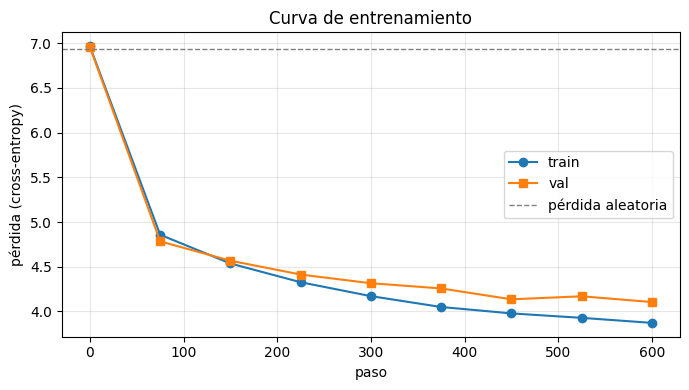

Pérdida val final: 4.1052 | perplejidad: 60.7
Si train baja mucho más que val, hay sobreajuste: más datos, más dropout o menos pasos.


In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history["step"], history["train"], marker="o", label="train")
ax.plot(history["step"], history["val"], marker="s", label="val")
ax.axhline(math.log(cfg.vocab_size), ls="--", c="gray", lw=1, label="pérdida aleatoria")
ax.set_xlabel("paso")
ax.set_ylabel("pérdida (cross-entropy)")
ax.set_title("Curva de entrenamiento")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

final = history["val"][-1]
print(f"Pérdida val final: {final:.4f} | perplejidad: {math.exp(final):.1f}")
print("Si train baja mucho más que val, hay sobreajuste: más datos, más dropout o menos pasos.")

## Paso 6 · Generación de texto

El modelo devuelve una distribución sobre el vocabulario. Cómo se muestrea cambia radicalmente
el resultado:

| Parámetro | Efecto |
|---|---|
| `temperature` < 1 | más determinista y repetitivo |
| `temperature` > 1 | más creativo y más incoherente |
| `top_k` | solo considera los k tokens más probables |
| `top_p` (nucleus) | solo la masa de probabilidad acumulada p; se adapta a cada paso |

In [ ]:
def generar(prompt="", max_new_tokens=200, temperature=0.9, top_k=50, top_p=None):
    ids = tok.encode(prompt) if prompt else [tok.encode("\n")[0]]
    idx = torch.tensor([ids], dtype=torch.long, device=device)
    out = model.generate(idx, max_new_tokens, temperature=temperature,
                         top_k=top_k, top_p=top_p, eos_id=EOS)
    return tok.decode(out[0].tolist())


for temp in [0.5, 1.0]:
    print(f"\n{'='*70}\ntemperature = {temp}\n{'='*70}")
    print(generar(text[:40], max_new_tokens=150, temperature=temp, top_k=50))


temperature = 0.5


First Citizen:
Before we proceed any fury,
Shall I's to the bount.

KING RICHARD II:
For 'tis all to the ears be sold to you,
Alst the days, and
The could I am hence to her hence,
Shre not, my peace, a brious,
And he did belerate, and sove
That I have post, and the watile of
To go, but become, find,
With chargerewasonturn, I were inst to his tears.
O, and my lords, if you, and youngland,
Comet,

temperature = 1.0


First Citizen:
Before we proceed any furjure duke of beste's,
For a gentleswer, I am belar?

LEONTES:
Plown, sir, I have, who, I will; I mets, and thou art?

Second Citizen:
I'Tis till you say you, I cohings; and let' you have not
To me of that you.

Proved
We have sed it?

VOLUMNY:
Ah, 'Mither of a medy is I have,
Her you have sorrow by this other, let me; int:
Bom, for you and the wal:
That I did


## Paso 7 · Guardar y cargar el modelo

Un checkpoint útil guarda **tres cosas**: pesos, configuración y tokenizador. Sin el tokenizador
exacto, los pesos no sirven para nada.

In [ ]:
os.makedirs("checkpoints", exist_ok=True)
torch.save({"model": model.state_dict(), "config": asdict(cfg), "history": history},
           "checkpoints/mi_llm.pt")
tok.save("checkpoints/tokenizer.json")
print("Guardado:", os.listdir("checkpoints"))

# Recarga desde cero y verificación
ckpt = torch.load("checkpoints/mi_llm.pt", map_location=device, weights_only=False)
tok2 = BPETokenizer.load("checkpoints/tokenizer.json")
model2 = GPT(GPTConfig(**ckpt["config"])).to(device)
model2.load_state_dict(ckpt["model"])
model2.eval()

X, Y = get_batch("val", cfg.block_size, 4)
model.eval()
with torch.no_grad():
    l1 = model(X, Y)[1].item()
    l2 = model2(X, Y)[1].item()
model.train()
assert abs(l1 - l2) < 1e-5 and tok2.encode("prueba") == tok.encode("prueba")
print(f"✅ Modelo y tokenizador recargados correctamente (pérdida {l1:.4f} == {l2:.4f})")

Guardado: ['tokenizer.json', 'mi_llm.pt']
✅ Modelo y tokenizador recargados correctamente (pérdida 4.0220 == 4.0220)


## Paso 8 · Fine-tuning por instrucciones (SFT)

El modelo pre-entrenado solo **continúa texto**. Para que siga instrucciones se hace un
*Supervised Fine-Tuning*: se entrena con pares `(instrucción, respuesta)` en un formato fijo.

La clave técnica es el **enmascarado de la pérdida**: se pone `-100` en las etiquetas de la parte
del prompt para que el modelo **solo sea penalizado por la respuesta**, no por reproducir la
pregunta.

Aquí el dataset se construye automáticamente a partir del propio corpus (tarea "continúa el
texto"), para que funcione en cualquier idioma. Sustitúyelo por tus pares reales cuando lo uses
en serio.

In [ ]:
PLANTILLA = "### Instrucción:\n{ins}\n\n### Respuesta:\n"


def construir_pares(text, n_pares=600, len_prompt=60, len_resp=90):
    rng = random.Random(0)
    pares = []
    for _ in range(n_pares):
        i = rng.randint(0, len(text) - (len_prompt + len_resp) - 1)
        fragmento = text[i:i + len_prompt]
        continuacion = text[i + len_prompt:i + len_prompt + len_resp]
        ins = f"Continúa este texto:\n{fragmento}"
        pares.append((PLANTILLA.format(ins=ins), continuacion))
    return pares


def tensores_sft(pares, tok, max_len):
    X, Y = [], []
    for prompt, resp in pares:
        p = tok.encode(prompt)
        r = tok.encode(resp) + [EOS]
        ids = (p + r)[:max_len + 1]
        lab = ([-100] * len(p) + r)[:max_len + 1]
        if len(ids) < max_len + 1:                       # padding
            pad = max_len + 1 - len(ids)
            ids += [0] * pad
            lab += [-100] * pad
        X.append(ids[:-1])
        Y.append(lab[1:])
    return torch.tensor(X), torch.tensor(Y)


pares = construir_pares(text)
Xs, Ys = tensores_sft(pares, tok, cfg.block_size)
print(f"{len(pares)} ejemplos | X: {tuple(Xs.shape)} | tokens supervisados: "
      f"{(Ys != -100).sum().item():,} de {Ys.numel():,}")
print("\n--- Ejemplo ---")
print(pares[0][0] + pares[0][1])

600 ejemplos | X: (600, 128) | tokens supervisados: 23,166 de 76,800

--- Ejemplo ---
### Instrucción:
Continúa este texto:
alters.

PERDITA:
One of these is true:
I think affliction m

### Respuesta:
ay subdue the cheek,
But not take in the mind.

CAMILLO:
Yea, say you so?
There shall not 


In [ ]:
SFT_STEPS = 150 if device == "cpu" else 600
SFT_LR = LEARNING_RATE * 0.1

opt_sft = configure_optimizer(model, WEIGHT_DECAY, SFT_LR)
model.train()
t0 = time.time()
for step in range(SFT_STEPS + 1):
    ix = torch.randint(len(Xs), (BATCH_SIZE,))
    xb, yb = Xs[ix].to(device), Ys[ix].to(device)
    _, loss = model(xb, yb)
    opt_sft.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
    opt_sft.step()
    if step % max(SFT_STEPS // 5, 1) == 0:
        print(f"paso {step:>4} | pérdida SFT {loss.item():.4f} | {time.time()-t0:.0f}s")
print("Fine-tuning terminado.")

con decay: 934,016 params | sin decay: 1,152 params


paso    0 | pérdida SFT 4.6936 | 0s


paso   30 | pérdida SFT 4.2018 | 8s


paso   60 | pérdida SFT 3.8424 | 15s


paso   90 | pérdida SFT 4.0034 | 22s


paso  120 | pérdida SFT 4.1393 | 30s


paso  150 | pérdida SFT 3.9260 | 38s
Fine-tuning terminado.


In [ ]:
fragmento = text[1000:1060]
prompt = PLANTILLA.format(ins=f"Continúa este texto:\n{fragmento}")
idx = torch.tensor([tok.encode(prompt)], dtype=torch.long, device=device)
salida = model.generate(idx, 90, temperature=0.8, top_k=40, eos_id=EOS)
generado = tok.decode(salida[0].tolist())[len(prompt):].split("<|fin|>")[0]

print(prompt + generado)
print("\n[el modelo aprendió a cerrar con <|fin|>: sabe cuándo parar]")
print("\n--- Continuación real del corpus (referencia) ---")
print(text[1060:1150])

### Instrucción:
Continúa este texto:
Second Citizen:
Would you proceed especially against Caius M

### Respuesta:
len, and give
d with the bachoice
Shound my puth, he, in all the dile,
I pray the none

[el modelo aprendió a cerrar con <|fin|>: sabe cuándo parar]

--- Continuación real del corpus (referencia) ---
arcius?

All:
Against him first: he's a very dog to the commonalty.

Second Citizen:
Consi


## Paso 9 · Cómo escalar

El pipeline que acabas de ejecutar es **el mismo** que usan los modelos grandes; cambian la escala
y algunas optimizaciones de ingeniería. Para subir de nivel:

**Configuraciones de referencia** (ejecuta la celda siguiente para ver parámetros y memoria):

**Qué añadir cuando crezcas**

1. **Precisión mixta** (`torch.autocast` + `bfloat16`): ~2× de velocidad en GPU moderna.
2. **Gradient accumulation**: simula batches grandes sin memoria extra.
3. **`F.scaled_dot_product_attention`**: FlashAttention integrado, sustituye a la atención manual
   (misma matemática, mucho menos consumo de memoria) usando `is_causal=True`.
4. **RoPE** en lugar de embeddings de posición aprendidos: mejor extrapolación de contexto.
5. **Datos, datos, datos**: la ley de Chinchilla sugiere ~20 tokens por parámetro. Un modelo de
   100 M pide ~2 000 M de tokens; con menos, es mejor entrenar un modelo más pequeño.
6. **`torch.compile(model)`**: aceleración adicional casi gratis en PyTorch ≥ 2.0.
7. **Checkpoints periódicos y logging** (Weights & Biases, TensorBoard): entrenamientos largos
   fallan; sin checkpoints, pierdes todo.

**Cuándo NO entrenar desde cero:** si el objetivo es un producto, un fine-tuning con LoRA sobre un
modelo abierto (Llama, Mistral, Qwen) da mejores resultados por varios órdenes de magnitud menos
de cómputo. Entrenar desde cero se justifica para aprender, para dominios muy particulares o
cuando necesitas control total sobre los datos.

In [ ]:
def estimar(vocab_size, block_size, n_layer, n_head, n_embd):
    emb = vocab_size * n_embd + block_size * n_embd
    por_capa = 4 * n_embd * n_embd + 8 * n_embd * n_embd   # atención + MLP
    total = emb + n_layer * por_capa + n_embd
    return total


configs = [
    ("juguete (CPU)",        1024,  128,  4,  4,  128),
    ("pequeño (1 GPU)",      4096,  256,  6,  6,  384),
    ("mediano (1 GPU 24GB)", 16384, 512, 12, 12,  768),
    ("GPT-2 124M",           50257, 1024, 12, 12, 768),
]
print(f"{'configuración':<22}{'vocab':>8}{'ctx':>6}{'capas':>7}{'d_model':>9}"
      f"{'params':>12}{'peso fp32':>12}")
for nombre, v, b, l, h, e in configs:
    p = estimar(v, b, l, h, e)
    print(f"{nombre:<22}{v:>8}{b:>6}{l:>7}{e:>9}{p/1e6:>10.1f} M{p*4/1e9:>10.2f} GB")

print("\nRegla práctica de memoria en entrenamiento (AdamW, fp32):")
print("  pesos + gradientes + 2 estados de Adam ≈ 16 bytes por parámetro,")
print("  más las activaciones (crecen con batch_size × block_size).")

configuración            vocab   ctx  capas  d_model      params   peso fp32
juguete (CPU)             1024   128      4      128       0.9 M      0.00 GB
pequeño (1 GPU)           4096   256      6      384      12.3 M      0.05 GB
mediano (1 GPU 24GB)     16384   512     12      768      97.9 M      0.39 GB
GPT-2 124M               50257  1024     12      768     124.3 M      0.50 GB

Regla práctica de memoria en entrenamiento (AdamW, fp32):
  pesos + gradientes + 2 estados de Adam ≈ 16 bytes por parámetro,
  más las activaciones (crecen con batch_size × block_size).


---
### Resumen

Has entrenado un LLM completo: tokenizador BPE propio, arquitectura Transformer decoder-only,
pre-entrenamiento auto-supervisado, generación con muestreo controlado, checkpoints y SFT con
enmascarado de pérdida.

**Ideas para seguir:**

- Cambia `CORPUS_PATH` por tus propios textos y vuelve a ejecutar todo.
- Sube `VOCAB_SIZE`, `n_layer` y `n_embd` y compara curvas de pérdida.
- Sustituye la atención manual por `F.scaled_dot_product_attention(..., is_causal=True)` y mide
  la diferencia de velocidad.
- Implementa RoPE y compara la extrapolación más allá de `block_size`.